#### Sequential Workflow with StateGraph

In [2]:
from langgraph.graph import StateGraph, END ,START
from typing import TypedDict

In [21]:
class BMIState(TypedDict):
    weight:float 
    height:float 
    bmi:float 
    healthtype:str 

In [27]:
BMIState.__annotations__

{'weight': float, 'height': float, 'bmi': float, 'healthtype': str}

In [28]:
def calculate_bmi(bmi_state:BMIState)->BMIState:
    weight = bmi_state['weight']
    height = bmi_state['height']
    return {"bmi":weight / (height ** 2)}

def bmi_category(bmistate: BMIState)-> BMIState:
    bmi = bmistate["bmi"]
    if bmi < 18.5:
        return {"healthtype":"Underweight"}
    elif bmi < 25:
        return {"healthtype":"Normal"}
    elif bmi < 30:
        return {"healthtype":"Overweight"}
    else:
        return {"healthtype":"Obese"}



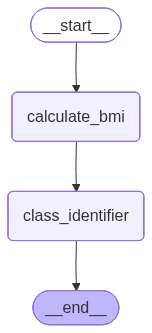

In [29]:
builder = StateGraph(BMIState) 
builder.add_node("calculate_bmi",calculate_bmi)
builder.add_node("class_identifier",bmi_category)

builder.add_edge(START,"calculate_bmi")
builder.add_edge("calculate_bmi","class_identifier")
builder.add_edge("class_identifier",END) 

graph = builder.compile()
graph 



In [30]:
# Input state
input_data = {
    "weight": 70,
    "height": 1.75
}

# Run the graph
result = graph.invoke(input_data)

# Output
print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.857142857142858, 'healthtype': 'Normal'}


#### Thank You